# Estimación de peso de pollos

## Colegio de Posgraduados

### COA661 Inteligencia Artificial

Profesor: Dr. Juan Manuel González Camacho

Entrega: José Alfredo Martínez

En este notebook se realiza el análisis de datos previo a el entrenamiento de modelos

In [1]:
# Librerias
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import joblib
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Código

In [2]:
# Cargar datos
datos = pd.read_excel('datosPesoPollo.xlsx')
fil, col = datos.shape

## Matriz de correlación entre $X$ y $Y$

<Axes: >

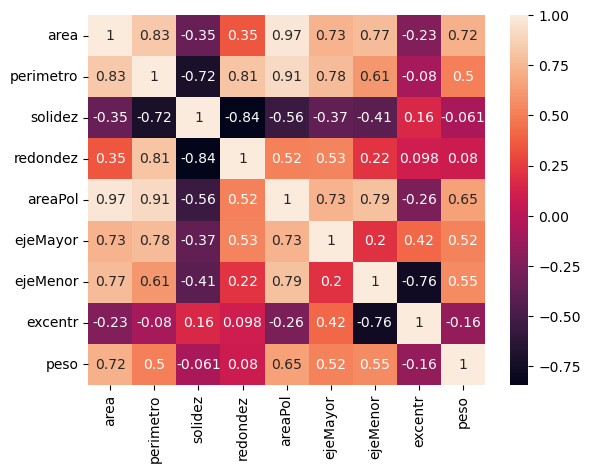

In [3]:
# Matriz de correlación
m = datos.iloc[:, 1 : col].corr()
sns.heatmap(m, annot = True)

In [4]:
# Datos
X = datos.iloc[:, 1 : col - 1].to_numpy()
Y = datos.iloc[:, col - 1].to_numpy()

In [5]:
# Datos de entrenamiento y test, aplicar proporción 80 : 20
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

print('Datos de entrenamiento: ', X_train.shape[0])
print('Datos de test: ', X_test.shape[0])

Datos de entrenamiento:  2439
Datos de test:  610


In [6]:
# Estandarizar la matriz de 8 características
sc8 = StandardScaler()

X_train_std = sc8.fit_transform(X_train)
X_test_std = sc8.transform(X_test)

In [7]:
# Extraer 5 características que más aportan al peso
X_train5 = X_train[:, [0, 1, 4, 5, 6]]
X_test5 = X_test[:, [0, 1, 4, 5, 6]]

In [8]:
# Estandarizar la matriz de 5 características
sc5 = StandardScaler()

X_train_std5 = sc5.fit_transform(X_train5)
X_test_std5 = sc5.transform(X_test5)

In [9]:
# Guardar datos de estandarización
joblib.dump(sc8, './T_scaler8.pkl')
joblib.dump(sc5, './T_scaler5.pkl')

['./T_scaler5.pkl']

## Importancia de características usando Random Forest

In [10]:
etiquetas = datos.columns[1 : col]

forest = RandomForestRegressor(n_estimators = 500, random_state = 42)
forest.fit(X_train, Y_train)

importancias = forest.feature_importances_

caracteristicas = pd.Series(importancias, index = datos.iloc[:, 1 : col - 1].columns)
caracteristicas = caracteristicas.sort_values(ascending = False)
acumulado = np.cumsum(caracteristicas.values)

print(caracteristicas)

area         0.642256
solidez      0.079118
ejeMayor     0.063649
ejeMenor     0.061147
excentr      0.054840
redondez     0.041367
perimetro    0.030512
areaPol      0.027110
dtype: float64


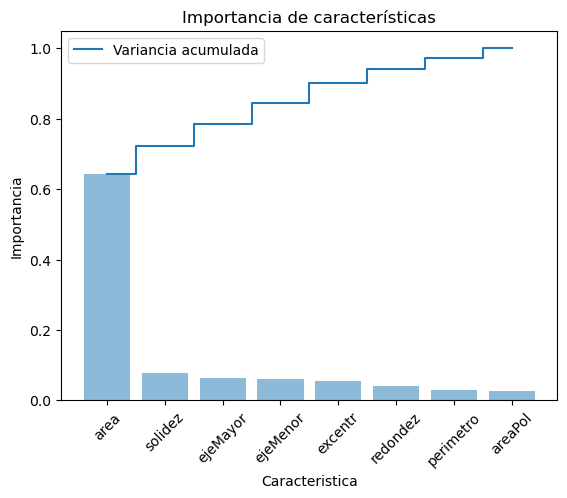

In [11]:
plt.bar(caracteristicas.index, caracteristicas.values, alpha = 0.5)
plt.step(range(0, caracteristicas.shape[0]), acumulado, where = 'mid', label = 'Variancia acumulada')

plt.ylabel('Importancia')
plt.xlabel('Caracteristica')
plt.xticks(rotation = 45)

plt.title('Importancia de características')
plt.legend(loc = 'upper left')

plt.show()

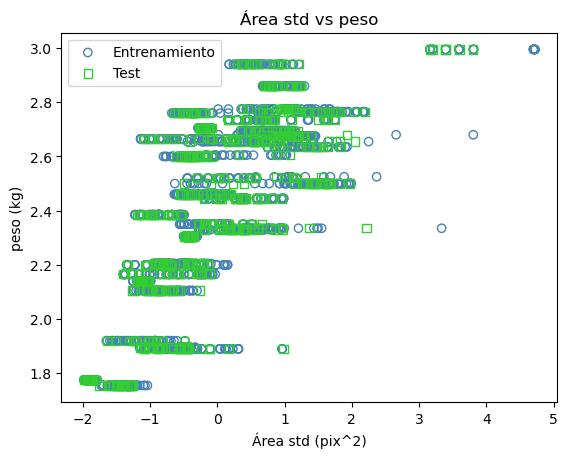

In [12]:
# Graficar datos
plt.scatter(X_train_std[:, 0], Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(X_test_std[:, 0], Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')

plt.xlabel('Área std (pix^2)')
plt.ylabel('peso (kg)')

plt.title('Área std vs peso')
plt.legend(loc = 'upper left')

plt.show()

In [13]:
# Extraer 3 características que más aportan al peso
X_train_rf = X_train[:, [0, 2, 5]]
X_test_rf = X_test[:, [0, 2, 5]]

In [14]:
# Estandarizar la matriz de 3 características
sc_rf = StandardScaler()

X_train_std_rf = sc_rf.fit_transform(X_train_rf)
X_test_std5_rf = sc_rf.transform(X_test_rf)

In [15]:
# Guardar datos de estandarización
joblib.dump(sc_rf, './T_scaler_rf.pkl')

['./T_scaler_rf.pkl']

## Principal Component Analisis PCA

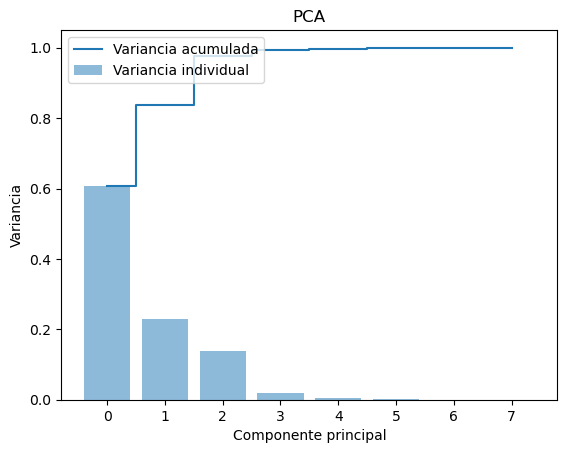

In [13]:
matriz_cov = np.cov(np.transpose(X_train_std))

eigen_vals, eigen_vecs = np.linalg.eig(matriz_cov)

total = sum(eigen_vals)
valores = [(i / total) for i in sorted(eigen_vals, reverse = True)]
acumulado = np.cumsum(valores)

plt.bar(range(0, len(valores)), valores, alpha = 0.5, align = 'center', label = 'Variancia individual')
plt.step(range(0, len(acumulado)), acumulado, where = 'mid', label = 'Variancia acumulada')

plt.ylabel('Variancia')
plt.xlabel('Componente principal')

plt.title('PCA')
plt.legend(loc = 'upper left')

plt.show()

In [14]:
# Calcular matriz de 2 componentes
pca2 = PCA(n_components = 2)
X_train_pca2 = pca2.fit_transform(X_train_std)
X_test_pca2 = pca2.transform(X_test_std)

print(X_train_pca2.shape)

(2439, 2)


In [15]:
# Calcular matriz de 3 componentes
pca3 = PCA(n_components = 3)
X_train_pca3 = pca3.fit_transform(X_train_std)
X_test_pca3 = pca3.transform(X_test_std)

print(X_train_pca3.shape)

(2439, 3)


In [16]:
# Guardar datos de PCA
joblib.dump(pca2, './T_PCA2.pkl')
joblib.dump(pca3, './T_PCA3.pkl')

['./T_PCA3.pkl']

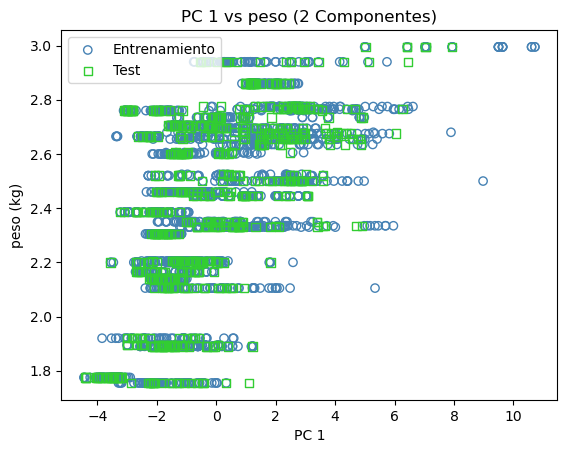

In [17]:
plt.scatter(X_train_pca2[:, 0], Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(X_test_pca2[:, 0], Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')

plt.xlabel('PC 1')
plt.ylabel('peso (kg)')

plt.title('PC 1 vs peso (2 Componentes)')
plt.legend(loc = 'upper left')

plt.show()

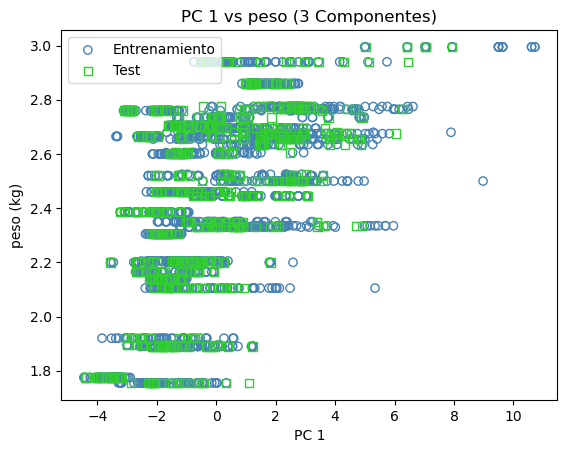

In [18]:
plt.scatter(X_train_pca3[:, 0], Y_train, marker = 'o', edgecolor = 'steelblue', facecolors = 'None', linestyle = 'None', label = 'Entrenamiento')
plt.scatter(X_test_pca3[:, 0], Y_test, marker = 's', edgecolor = 'limegreen', facecolors = 'None', linestyle = 'None', label = 'Test')

plt.xlabel('PC 1')
plt.ylabel('peso (kg)')

plt.title('PC 1 vs peso (3 Componentes)')
plt.legend(loc = 'upper left')

plt.show()

## Guardar los datos

In [19]:
# Guardar datos de Train y test
X1 = pd.DataFrame(np.hstack((X_train, Y_train.reshape(-1, 1))), columns = [f'A{i}' for i in range(X_train.shape[1] + 1)])
X2 = pd.DataFrame(np.hstack((X_test, Y_test.reshape(-1, 1))), columns = [f'A{i}' for i in range(X_test.shape[1] + 1)])

with pd.ExcelWriter('./misDatos.xlsx') as writer:
    X1.to_excel(writer, index = False, sheet_name = 'X_train')
    X2.to_excel(writer, index = False, sheet_name = 'X_test')